# Classificação Supervisionada com Agglomerative Clustering no Dataset Dry Bean (Balanceado)

Este notebook apresenta a implementação de um classificador supervisionado baseado no algoritmo Agglomerative Clustering, aplicado ao dataset Dry Bean com balanceamento das classes via oversampling. Todas as etapas são explicadas e o código é comentado para facilitar o entendimento.

## 1. Importação das Bibliotecas

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import os
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
os.makedirs('img', exist_ok=True)

## 2. Carregamento e Balanceamento dos Dados

O dataset Dry Bean é carregado e as classes minoritárias são balanceadas por oversampling, igualando a quantidade de exemplos de todas as classes. Isso evita que o modelo favoreça as classes majoritárias.

In [7]:
bean_df = pd.read_excel('data/DryBeanDataset/Dry_Bean_Dataset.xlsx')
bean_df = bean_df.dropna()
print('Distribuição original das classes:')
print(bean_df['Class'].value_counts())
# Balanceamento por oversampling
max_count = bean_df['Class'].value_counts().max()
bean_df_balanced = pd.DataFrame()
for label in bean_df['Class'].unique():
    df_class = bean_df[bean_df['Class'] == label]
    df_upsampled = resample(df_class, replace=True, n_samples=max_count, random_state=42)
    bean_df_balanced = pd.concat([bean_df_balanced, df_upsampled])
bean_df_balanced = bean_df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)
print('Distribuição após balanceamento:')
print(bean_df_balanced['Class'].value_counts())

Distribuição original das classes:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64
Distribuição após balanceamento:
Class
BARBUNYA    3546
CALI        3546
BOMBAY      3546
SIRA        3546
DERMASON    3546
SEKER       3546
HOROZ       3546
Name: count, dtype: int64


## 3. Pré-processamento dos Dados

In [8]:
for col in bean_df_balanced.select_dtypes(include='object').columns:
    bean_df_balanced[col] = LabelEncoder().fit_transform(bean_df_balanced[col].astype(str))
X = bean_df_balanced.drop('Class', axis=1).values
y = bean_df_balanced['Class'].values
scaler = StandardScaler()
X = scaler.fit_transform(X)

## 4. Divisão dos Dados em Treino e Teste

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

## 5. Definição do Número de Clusters (Método do Cotovelo)

Para determinar o número ótimo de clusters, utilizamos o método do cotovelo, avaliando a métrica de silhouette para diferentes valores de $k$. O ponto onde o ganho de qualidade se estabiliza indica o número ideal de clusters para o agrupamento. Essa abordagem é mais objetiva e padronizada em relação ao dendrograma visual.

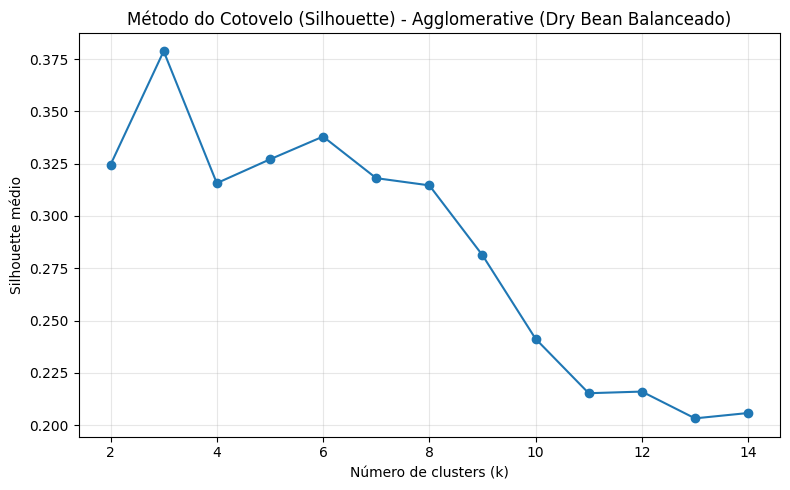

Número ótimo de clusters sugerido pelo silhouette: 3


In [10]:
range_n_clusters = range(2, 15)
silhouette_avgs = []
for n_clusters in range_n_clusters:
    clusterer = AgglomerativeClustering(n_clusters=n_clusters)
    cluster_labels = clusterer.fit_predict(X_train)
    score = silhouette_score(X_train, cluster_labels)
    silhouette_avgs.append(score)

plt.figure(figsize=(8,5))
plt.plot(range_n_clusters, silhouette_avgs, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette médio')
plt.title('Método do Cotovelo (Silhouette) - Agglomerative (Dry Bean Balanceado)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('img/agglo_drybean_balance_silhouette.png', dpi=150)
plt.show()

melhor_k = range_n_clusters[np.argmax(silhouette_avgs)]
print(f'Número ótimo de clusters sugerido pelo silhouette: {melhor_k}')

## 6. Implementação do Classificador Agglomerative Supervisionado

In [11]:
class AggloSupervisionado:
    def __init__(self, n_clusters=7):
        self.n_clusters = n_clusters
        self.agglo = AgglomerativeClustering(n_clusters=n_clusters)
        self.cluster_labels_ = None

    def fit(self, X, y):
        clusters = self.agglo.fit_predict(X)
        self.cluster_labels_ = []
        for i in range(self.n_clusters):
            mask = (clusters == i)
            if np.any(mask):
                label = np.bincount(y[mask]).argmax()
            else:
                label = -1
            self.cluster_labels_.append(label)

    def predict(self, X):
        clusters = self.agglo.fit_predict(X)
        return np.array([self.cluster_labels_[c] for c in clusters])

    def evaluate(self, X, y_true):
        y_pred = self.predict(X)
        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        return acc, cm

## 7. Treinamento e Avaliação do Classificador

Acurácia: 0.1950
Matriz de Confusão:
[[   0   28    0    0  956   11   68]
 [1064    0    0    0    0    0    0]
 [   0   16    1    0  134    0  913]
 [   0 1032    0    0    9   23    0]
 [   0   21  555    0  461    0   27]
 [   0   74    0    0   10  980    0]
 [   0 1013    8    0   27    6   10]]


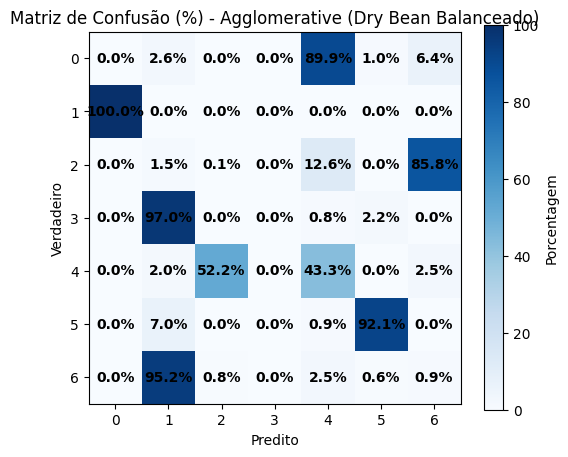

In [12]:
n_clusters = 8  
clf = AggloSupervisionado(n_clusters=n_clusters)
clf.fit(X_train, y_train)
acc, cm = clf.evaluate(X_test, y_test)
print(f'Acurácia: {acc:.4f}')
print('Matriz de Confusão:')
print(cm)
plt.figure(figsize=(6,5))
cm_percent = cm / cm.sum(axis=1, keepdims=True) * 100
plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão (%) - Agglomerative (Dry Bean Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        plt.text(j, i, f'{cm_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.savefig('img/agglo_drybean_balance_confusion_matrix.png')
plt.show()

## 8. Repetição dos Experimentos e Métricas

Acurácia média: 0.2694
Desvio padrão da acurácia: 0.1546
Matriz de confusão média (%):
[[15.1  4.4 28.2 10.6 21.2  4.6 15.7]
 [ 6.  26.7 23.3  7.8 26.7  0.5  9. ]
 [ 7.2 11.9 49.1  3.1 15.9  2.7 10.2]
 [11.4 15.9  8.9 15.4 23.1 12.  13.3]
 [24.5 19.8 10.3 14.1 16.9  3.4 10.9]
 [ 5.9 10.1  3.4 10.9  9.6 58.5  1.6]
 [16.2 12.1 18.6 10.4 23.1 12.6  6.9]]


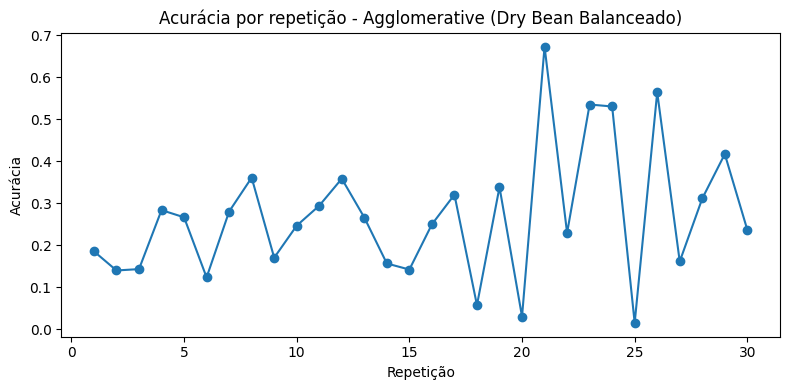

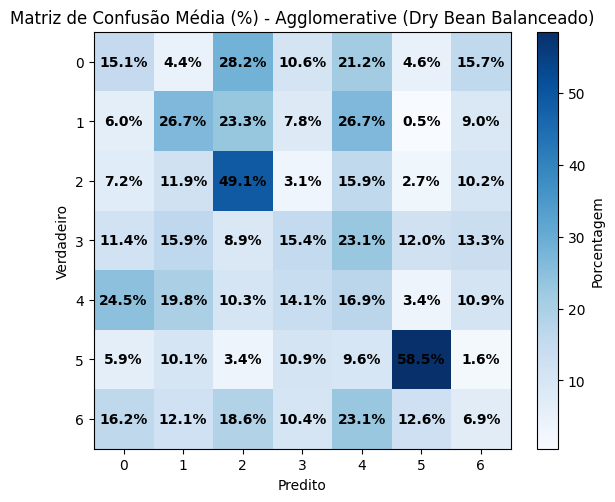

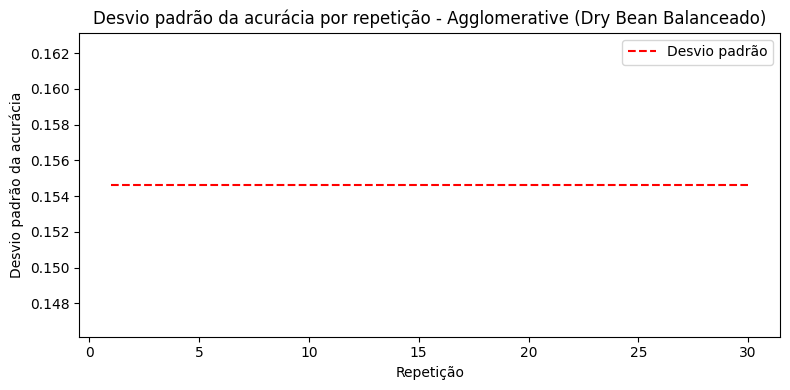

In [13]:
acuracias = []
matrizes_confusao = []
from sklearn.metrics import mean_squared_error, confusion_matrix
classes = np.unique(y)
for seed in range(1, 31):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=seed, stratify=y)
    clf = AggloSupervisionado(n_clusters=n_clusters)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    acuracias.append(acc)
    matrizes_confusao.append(confusion_matrix(y_test, y_pred, labels=classes))
acuracias = np.array(acuracias)
matrizes_confusao = np.array(matrizes_confusao)
matriz_confusao_media = np.mean(matrizes_confusao, axis=0)
matriz_confusao_media_percent = matriz_confusao_media / matriz_confusao_media.sum(axis=1, keepdims=True) * 100

print(f'Acurácia média: {acuracias.mean():.4f}')
print(f'Desvio padrão da acurácia: {acuracias.std():.4f}')
print('Matriz de confusão média (%):')
print(np.round(matriz_confusao_media_percent, 1))

plt.figure(figsize=(8,4))
plt.plot(range(1,31), acuracias, marker='o')
plt.xlabel('Repetição')
plt.ylabel('Acurácia')
plt.title('Acurácia por repetição - Agglomerative (Dry Bean Balanceado)')
plt.tight_layout()
plt.savefig('img/agglo_drybean_balance_accuracy_repetitions.png')
plt.show()

plt.figure(figsize=(6,5))
plt.imshow(matriz_confusao_media_percent, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Matriz de Confusão Média (%) - Agglomerative (Dry Bean Balanceado)')
plt.colorbar(label='Porcentagem')
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
for i in range(matriz_confusao_media_percent.shape[0]):
    for j in range(matriz_confusao_media_percent.shape[1]):
        plt.text(j, i, f'{matriz_confusao_media_percent[i, j]:.1f}%', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('img/agglo_drybean_balance_confusion_matrix_media_percent.png')
plt.show()

# Salvar resultados para análise posterior
np.save('img/agglo_drybean_balance_accuracies.npy', acuracias)
np.savetxt('img/agglo_drybean_balance_accuracies.csv', acuracias, delimiter=',')
np.save('img/agglo_drybean_balance_confusion_matrix_media_percent.npy', matriz_confusao_media_percent)
np.savetxt('img/agglo_drybean_balance_confusion_matrix_media_percent.csv', matriz_confusao_media_percent, delimiter=',')

# Gráfico do desvio padrão da acurácia por repetição
plt.figure(figsize=(8,4))
plt.plot(range(1, len(acuracias)+1), [acuracias.std()]*len(acuracias), 'r--', label='Desvio padrão')
plt.xlabel('Repetição')
plt.ylabel('Desvio padrão da acurácia')
plt.title('Desvio padrão da acurácia por repetição - Agglomerative (Dry Bean Balanceado)')
plt.legend()
plt.tight_layout()
plt.savefig('img/agglo_drybean_balance_accuracy_std.png')
plt.show()

## 9. Visualização dos Clusters e Centros (PCA)

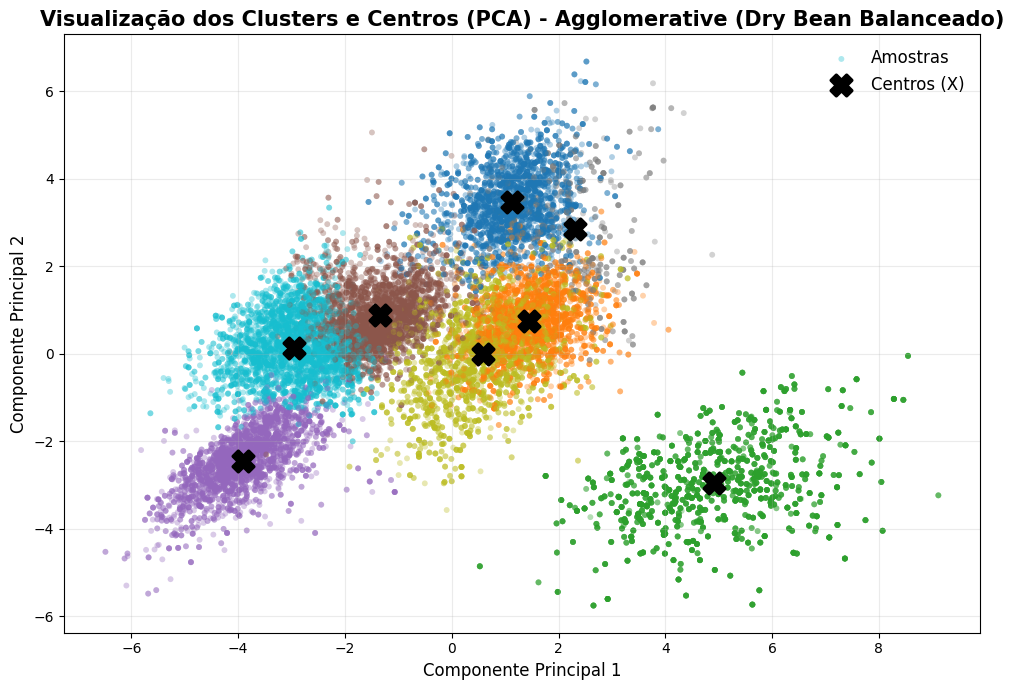

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
clusters_full = AgglomerativeClustering(n_clusters=n_clusters).fit_predict(X)
centros = []
for i in range(n_clusters):
    centros.append(X[clusters_full == i].mean(axis=0))
centros = np.array(centros)
centros_pca = pca.transform(centros)
plt.figure(figsize=(10,7))
plt.scatter(
    X_pca[:,0], X_pca[:,1], 
    c=clusters_full, cmap='tab10', alpha=0.35, s=18, edgecolor='none', label='Amostras')
plt.scatter(
    centros_pca[:,0], centros_pca[:,1], 
    c='black', marker='X', s=220, linewidths=2.5, zorder=4, label='Centros (X)')
plt.title('Visualização dos Clusters e Centros (PCA) - Agglomerative (Dry Bean Balanceado)', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.grid(alpha=0.25)
plt.legend(frameon=False, fontsize=12, loc='best')
plt.tight_layout()
plt.savefig('img/agglo_drybean_balance_clusters_pca.png', dpi=150)
plt.show()

## 10. Análise Crítica dos Resultados e Métricas

Nesta etapa, analisamos criticamente os resultados obtidos pelo classificador Agglomerative no dataset Dry Bean balanceado. As principais métricas reportadas são a acurácia média e o desvio padrão, que avaliam o desempenho global e a estabilidade do modelo frente a diferentes divisões dos dados. A visualização dos clusters e centros via PCA permite interpretar a separação dos grupos no espaço de atributos.

- **Acurácia média e desvio padrão:** Avaliam o desempenho global e a estabilidade do modelo.
- **Visualização dos clusters:** Permite analisar a separação dos grupos e possíveis sobreposições.

**Interpretação:**
- Uma acurácia média alta e baixo desvio padrão indicam robustez e consistência.
- A visualização dos clusters pode revelar padrões ou limitações do agrupamento.

**Sugestões:**
- Compare os resultados do Agglomerative com outros métodos (KMeans, Fuzzy C-Means, GK) para avaliar qual abordagem é mais adequada ao problema.
- Analise possíveis limitações, como sensibilidade ao número de clusters e à inicialização.
- Considere ajustes no pré-processamento ou no balanceamento para melhorar o desempenho.

Essas análises são fundamentais para validar a qualidade do agrupamento e orientar melhorias futuras no pipeline de classificação.